In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
weights = pd.read_csv("original_data/weights1.csv")
weights2 = pd.read_csv("original_data/weights2.csv")
weights = pd.concat([weights, weights2], ignore_index=True)
weights

,OCCURNUM,qstnum,repwgt0,repwgt1,repwgt2,repwgt3,repwgt4,repwgt5,repwgt6,repwgt7,...,repwgt151,repwgt152,repwgt153,repwgt154,repwgt155,repwgt156,repwgt157,repwgt158,repwgt159,repwgt160
0,1,14,18354163,10438492,10407387,28068302,25562833,9239434,25338398,25701567,...,10895492,31037674,9263588,24989376,8651019,23992521,27458755,22802523,26921460,9028737
1,2,14,15592437,8650848,7739514,23599044,22150186,7661903,20928499,24058785,...,9142763,27457903,8064288,19715055,7889177,20023445,24539323,20821892,22804294,7763269
2,1,15,16356249,8971846,7819705,24359971,21130796,8033700,24966868,21950496,...,8970494,22956112,9292178,25490285,7864233,23294925,19066812,23322929,23187256,8032997
3,1,16,20773863,12256987,10094193,28950309,26670581,8927895,30159278,31383567,...,12579129,30210036,11522337,27180683,9795101,25067470,27903109,29132044,28331760,10088447
4,2,16,16796510,9358118,8017431,25625108,24611988,8170753,24141884,24525276,...,9598023,22642743,10367559,21832240,9384531,22057325,25366842,23213102,23656517,8461291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99058,1,69460,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99059,1,69461,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99060,2,69461,3332493,3369042,3339441,1046782,5289272,3467648,3184734,3487858,...,3398154,3455348,3389339,972960,5565823,1068255,3141941,5549270,5110794,5729614
99061,1,69464,2790829,2731309,837142,830413,4724120,5051157,2624563,5274098,...,4617975,2631165,807997,2960079,812894,4881043,2910442,964690,834369,2604438


In [53]:
data = pd.read_csv('original_data/nov24pub_first_half.csv')
data2 = pd.read_csv('original_data/nov24pub_second_half.csv')
data = pd.concat([data, data2], ignore_index=True)
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,84055620110148,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,521800504640811,11,2024,1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,510421864001780,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,7180159540041,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,71062004118993,11,2024,-1,219,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126681,658604017243570,11,2024,-1,218,NaN,2,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126682,140784500685805,11,2024,-1,218,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126683,181202500665725,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126684,940325328011460,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [54]:
def filter_rows_by_negative_one_pct(df, threshold=0.2, missing_value=-1, inplace=False):
    # threshold: fraction of cols with missing_value to mark row as bad
    # e.g. 0.5 means ">= 50% of columns are -1"
    bad = (df == missing_value).sum(axis=1) / df.shape[1] >= threshold
    bad = (df < 0).sum(axis=1) / df.shape[1] >= threshold
    n_bad = int(bad.sum())
    n_total = len(df)
    print(f"{n_bad} rows out of {n_total} have >= {threshold*100:.1f}% of columns == {missing_value}")
    if inplace:
        df.drop(index=df[bad].index, inplace=True)
        print(f"dropped {n_bad} rows, remaining {len(df)} rows")
        return df
    df_clean = df.loc[~bad].reset_index(drop=True)
    print(f"returning cleaned df with {len(df_clean)} rows")
    return df_clean

### USED TO CREATE PRE AND POST DROP COMPARISON PLOTS --- IGNORE ---

# df_clean = filter_rows_by_negative_one_pct(data)

# thresholds = np.linspace(0.0, 1.0, 101)
# remaining_counts = []

# for t in thresholds:
#     df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
#     remaining_counts.append(len(df_tmp))

# print("data original shape:", data.shape)
# print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

# plt.figure(figsize=(8, 5))
# plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
# plt.xlabel("threshold % of columns == -1")
# plt.ylabel("rows remaining")
# plt.title("Rows remaining after filtering at each -1 threshold PreDrop")
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(remaining_counts, bins=20, edgecolor="k")
# plt.xlabel("rows remaining")
# plt.ylabel("frequency")
# plt.title("Histogram of remaining row counts over thresholds")
# plt.show()


In [55]:
data['HRINTSTA'].value_counts()

# 1 = Interview

# 2 = Type A Noninterview (These records represent households that were eligible
# for the November CPS interview but were not interviewed because no one was
# home, household members were temporarily absent, etc.)

# 3 = Type B Noninterview (These records represent sample addresses determined to
# be ineligible for the CPS by virtue of a temporary situation, such as being
# vacant, nonresidential, etc. These households could become eligible for a CPS
# interview.)

# 4 = Type C Noninterview (These recordsrepresentsample addresses determined to be
# ineligible for CPS by virtue of a permanent change such as demolished,
# condemned, etc. These addresses will not be visited again for CPS interviews.)

# We should only keep rows where HRINTSTA == 1, as these are the only rows that represent actual interviews. The other rows represent non-interviews or ineligible addresses, which are not useful for our analysis.
data = data[data['HRINTSTA'] == 1].reset_index(drop=True)

In [56]:
### PRCITSHP (CITIZENSHIP STATUS)

# 1 NATIVE, BORN IN THE UNITED STATES
# 2 NATIVE, BORN IN PUERTO RICO OR OTHER U.S. ISLAND AREAS
# 3 NATIVE, BORN ABROAD OF AMERICAN PARENT OR PARENTS
# 4 FOREIGN BORN, U.S. CITIZEN BY NATURALIZATION
# 5 FOREIGN BORN, NOT A CITIZEN OF THE UNITED STATES

# We should only keep rows where PRCITSHP != 5, as these are the only rows that represent elgible voters.

data = data[data['PRCITSHP'] != 5].reset_index(drop=True)


### PRCITSHP (CITIZENSHIP STATUS)

# 1 = Child household member (0-14 years old)
# 2 = Adult household member (15 years and older)
# 3 = Reference person (the first adult household member listed in the household roster)

# We need to drop rows where PRPERTYP == 1, as these represent child household members who are not eligible voters and do not provide useful information for our analysis. 
data = data[data['PRPERTYP'] != 1].reset_index(drop=True)

In [57]:
data = data.drop(columns=[col for col in data.columns if col.startswith('PX') or col.startswith('HX')])

# Used to Drop Flags and Allocation Weights, which are not useful for our analysis and may introduce noise or bias into our models. These columns often contain binary indicators or weights that are specific to the survey design and may not be relevant for predicting voter turnout or registration status. By dropping these columns, we can focus on the demographic and socioeconomic features that are more likely to be informative for our analysis.

In [58]:
### MADE A READABLE VERSION OF THE CATEGORICAL VARIABLES USING THE CODEBOOK

LABELS = {
    "PESEX":    {1: "Male", 2: "Female"},
    "PEHSPNON": {1: "Hispanic", 2: "Non-Hispanic"},
    "PRCITSHP": {1: "Native-born", 2: "Born PR/territory",
                 3: "Born abroad-US parents", 4: "Naturalized", 5: "Non-citizen"},
    "PEEDUCA":  {
        31: "Less than 1st grade", 32: "1st-4th grade", 33: "5th-6th grade",
        34: "7th-8th grade", 35: "9th grade", 36: "10th grade",
        37: "11th grade", 38: "12th no diploma", 39: "HS diploma/GED",
        40: "Some college", 41: "Associate-vocational", 42: "Associate-academic",
        43: "Bachelor's", 44: "Master's", 45: "Professional", 46: "Doctorate",
    },
    "PRMARSTA": {1: "Married-civ spouse", 2: "Married-AF spouse",
                 3: "Married-spouse absent", 4: "Widowed",
                 5: "Divorced", 6: "Separated", 7: "Never married"},
    "PEMLR":    {1: "Employed-at work", 2: "Employed-absent",
                 3: "Unemployed-layoff", 4: "Unemployed-looking",
                 5: "NILF-retired", 6: "NILF-disabled", 7: "NILF-other"},
    "PTDTRACE": {1: "White", 2: "Black", 3: "AI/AN", 4: "Asian",
                 5: "PI", 6: "White-Black", 7: "White-AI/AN", 8: "White-Asian",
                 9: "White-PI", 10: "Black-AI/AN", 11: "Black-Asian",
                 12: "Black-PI", 13: "AI/AN-Asian",
                 14: "Asian-PI", 15: "White-Black-AI/AN", 16: "White-Black-Asian",
                 17: "White-Black-PI", 18: "White-AI/AN-Asian",
                 19: "White-AI/AN-PI", 20: "White-Asian-PI",
                 21: "Black-AI/AN-Asian", 22: "Black-AI/AN-PI",
                 23: "Black-Asian-PI", 24: "AI/AN-Asian-PI",
                 25: "White-Black-AI/AN-Asian", 26: "Other 3+ race combo"},
    "GTMETSTA": {1: "Principal city", 2: "Balance of metro", 3: "Nonmetropolitan"},
    "PEAFEVER": {1: "Veteran", 2: "Non-veteran"},
    "PRDISFLG": {1: "Has disability", 2: "No disability"},
    "HEFAMINC": {
        1: "<$5k", 2: "$5-7.5k", 3: "$7.5-10k", 4: "$10-12.5k",
        5: "$12.5-15k", 6: "$15-20k", 7: "$20-25k", 8: "$25-30k",
        9: "$30-35k", 10: "$35-40k", 11: "$40-50k", 12: "$50-60k",
        13: "$60-75k", 14: "$75-100k", 15: "$100-150k", 16: "$150k+",
    },
}
readable_data = data.copy()

MISSING_SENTINEL = [-1, -2, -3, -9]

for col, mapping in LABELS.items():
    if col in readable_data.columns:
        readable_data[col] = readable_data[col].replace(MISSING_SENTINEL, np.nan).map(mapping)

readable_data.head()

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,6,4,2
1,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,6,4,1
2,50057098511186,11,2024,1,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,9,4,1
3,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,-2,4,1
4,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,-2,4,1


In [59]:
(data.where(data == -1).count() / len(data) * 100).sort_values(ascending=False).head(90)
# We can also get rid of columns that have a certain percentage of NA values, as these are also likely to be uninformative. 
# We can also get rid of columns that have a certain percentage of 0 values, as these are also likely to be uninformative. 


### Values that have 0% of -1 values (i.e. no missing data)

# HRHHID    HOUSEHOLD IDENTIFIER
# GTCBSA    SPECIFIC METROPOLITAN CBSA CODE  (SEE GEOGRAPHIC ATTACHMENT)
# GTCO      FIPS COUNTY CODE
# GTCBSAST  PRINCIPAL CITY/BALANCE STATUS 
# GTMETSTA  METROPOLITAN STATUS
# GTINDVPC  INDIVIDUAL PRINCIPAL CITY
# GTCBSASZ  Metropolitan Area (CBSA) SIZE (Population)
# GTCSA     Consolidated Statistical Area (CSA) FIPS CODE (SEE GEOGRAPHIC ATTACHMEN
# PTWK      WEEKLY EARNINGS – TOP CODE ****
# PRTFAGE   TOP CODE FLAG FOR AGE **** 
# PWCMPWGT  Composited Final Weight. Used to create BLS's published labor force statistics (4 implied decimal places)
# PTOT      WEEKLY OVERTIME AMOUNT – TOP CODE ****
# GEDIV     DIVISION
# OCCURNUM  Unique person identifier. Valid only within any specific month. 
# HXPHONEO  ALLOCATION FLAG 
# HXTELAVL  ALLOCATION FLAG  
# HXTELHHD  ALLOCATION FLAG
# HXFAMINC  ALLOCATION FLAG
# HXHOUSUT  ALLOCATION FLAG
# HXTENURE  ALLOCATION FLAG
# PWFMWGT   FAMILY WEIGHT (4 IMPLIED DECIMALS) ONLY USED FOR TALLYING FAMILY CHARACTERISTICS.
# PWLGWGT   LONGITUDINAL WEIGHT (4 IMPLIED DECIMALS) ONLY FOUND ON ADULT RECORDS MATCHED FROM MONTH TO MONTH. (USED FOR GROSS FLOWS ANALYSIS)
# PWORWGT   OUTGOING ROTATION WEIGHT (4 IMPLIED DECIMALS) USED FOR TALLYING INFORMATION COLLECTED ONLY IN 
# PWSSWGT   FINAL WEIGHT (4 IMPLIED DECIMAL PLACES) USED FOR MOST TABULATIONS, CONTROLLED TO INDEPENDENT ESTIMATES FOR 1) STATES; 2) ORIGIN, SEX, AND AGE; AND 3) AGE, RA 
# PWVETWGT  VETERANS WEIGHT (4 IMPLIED DECIMALS) USED FOR TALLYING VETERAN'S DATA ONLY, CONTROLLED TO ESTIMATES OF VETERANS SUPPLIED BY
# QSTNUM    Unique household identifier. Valid only within any specific month. 
# GEREG     REGION
# GESTFIPS  STATE CODE
# HUFINAL   FINAL OUTCOME CODE 
# PTHR      HOURLY PAY – TOP CODE ****
# HWHHWGT   HOUSEHOLD WEIGHT (4 IMPLIED DECIMAL PLACES) USED FOR TALLYING HOUSEHOLD CHARACTERISTICS  
# HEPHONEO  IS A TELEPHONE INTERVIEW ACCEPTABLE?
# HRNUMHOU  TOTAL NUMBER OF PERSONS LIVING IN THE HOUSEHOLD (HOUSEHOLD MEMBERS)
# HRHTYPE   HOUSEHOLD TYPE
# HRMIS     MONTH-IN-SAMPLE 
# HRLONGLK  LONGITUDINAL LINK INDICATOR EDITED UNIVERSE: ALL HHLDs IN SAMPLE 
# HRHHID2   HOUSEHOLD IDENTIFIER (part 2)
# HRYEAR4   YEAR OF INTERVIEW
# HEHOUSUT  TYPE OF HOUSING UNIT
# HRMONTH   MONTH OF INTERVIEW 
# HUPRSCNT  NUMBER OF ACTUAL AND ATTEMPTED PERSONAL CONTACTS






# Identify columns where all values are -1
cols_to_drop = [col for col in data.columns if (data[col] == -1).all()]

# Drop those columns from data
data = data.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")

Dropped 9 columns: ['HUTYPEA', 'HUTYPC', 'PULKDK3', 'PULKDK4', 'PULKDK5', 'PULKDK6', 'PULKPS4', 'PULKPS5', 'PULKPS6']


In [60]:
for df_name in ['data', 'data2']:
    if df_name in globals():
        df = globals()[df_name]
        keep = ~(df == -1).all(axis=1)
        globals()[df_name] = df.loc[keep].reset_index(drop=True)
        print(f"{df_name}: removed {len(df) - keep.sum()} rows, remaining {keep.sum()}")

data: removed 0 rows, remaining 76417
data2: removed 0 rows, remaining 63343


76417 rows out of 76417 have >= 20.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 0.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 1.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 2.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 3.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 4.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 5.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 6.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 7.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 8.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 9.0% of columns == -1
returning cleaned df with 0 rows
76417 rows out of 76417 have >= 10.0% of c

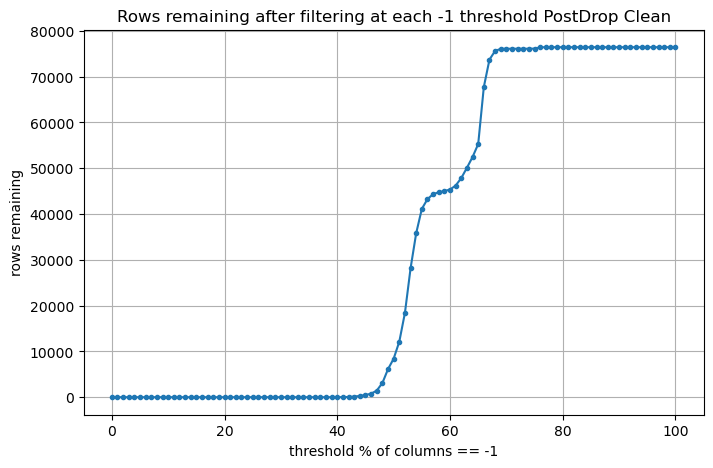

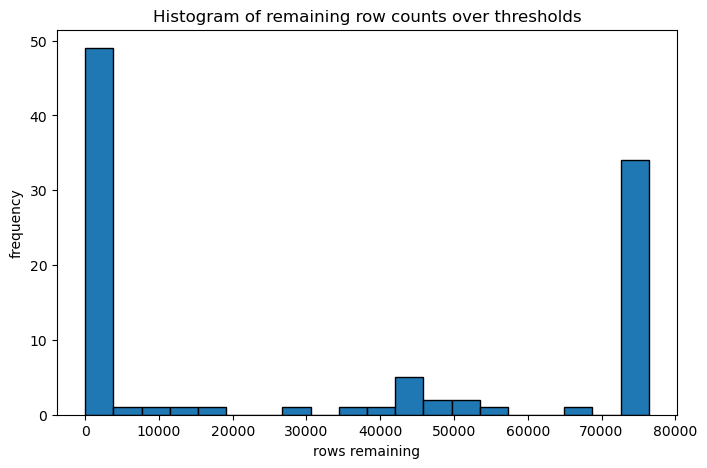

In [61]:
df_clean = filter_rows_by_negative_one_pct(data)

thresholds = np.linspace(0.0, 1.0, 101)
remaining_counts = []

for t in thresholds:
    df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
    remaining_counts.append(len(df_tmp))

print("data original shape:", data.shape)
print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

plt.figure(figsize=(8, 5))
plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
plt.xlabel("threshold % of columns == -1")
plt.ylabel("rows remaining")
plt.title("Rows remaining after filtering at each -1 threshold PostDrop Clean")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(remaining_counts, bins=20, edgecolor="k")
plt.xlabel("rows remaining")
plt.ylabel("frequency")
plt.title("Histogram of remaining row counts over thresholds")
plt.show()

In [62]:
data['PRPERTYP'].value_counts(dropna=False)

PRPERTYP
2    76086
3      331
Name: count, dtype: int64

In [63]:
len(data['GESTFIPS'].unique())

51

In [64]:
corr = data.corr()[['PES1', 'PES2']]
corr_sorted = corr.abs().sort_values(by=['PES1', 'PES2'], ascending=False)
corr_sorted

,PES1,PES2
PES1,1.000000,0.567043
PRS8,0.641803,0.131575
PESCK4,0.579743,0.219685
PES2,0.567043,1.000000
PES3,0.369994,0.739172
...,...,...
PTNMEMP1,0.000083,0.006063
HRMONTH,NaN,NaN
HRYEAR4,NaN,NaN
FILLER,NaN,NaN


In [66]:
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,6,4,2
1,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,6,4,1
2,50057098511186,11,2024,1,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,9,4,1
3,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,-2,4,1
4,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,-2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76412,51142740850196,11,2024,1,201,NaN,1,5,1,-1,...,2,-1,-1,-1,-1,-1,-1,-1,-1,-1
76413,651408019271540,11,2024,1,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,1,8,4,1
76414,651408019271540,11,2024,1,201,NaN,1,1,1,-1,...,1,2,-2,-1,-1,-1,-1,-1,4,2
76415,75183059016886,11,2024,2,201,NaN,1,1,1,-1,...,1,1,-1,-1,-1,1,2,8,4,2
